# 04 - Model Explainability

## Objective

This notebook explains the predictions of the champion model using SHAP (SHapley Additive exPlanations).

The goal is to understand:

- which features most influence fee-defaulter risk predictions
- whether the model is relying on sensible signals
- how individual student-level predictions can be interpreted.

In [ ]:
pip install shap

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

Mounted at /content/drive


In [ ]:
project_root = Path("/content/drive/MyDrive/fee-defaulter-prediction")

model_path = project_root / "models" / "best_model.pkl"
X_train_path = project_root / "data" / "processed" / "03_best_X_train.csv"
X_test_path = project_root / "data" / "processed" / "03_best_X_test.csv"
y_train_path =  project_root / "data" / "processed" / "03_best_y_train.csv"
y_test_path = project_root / "data" / "processed" / "03_best_y_test.csv"

(project_root / "reports" / "figures").mkdir(parents=True, exist_ok=True)

In [ ]:
best_model = joblib.load(model_path)

X_train_best = pd.read_csv(X_train_path)
X_test_best = pd.read_csv(X_test_path)
y_test_best = pd.read_csv(y_test_path).squeeze()

print("X_train shape:", X_train_best.shape)
print("X_test shape:", X_test_best.shape)
print("y_best shape:", y_test_best.shape)


X_train shape: (316, 36)
X_test shape: (79, 36)
y_best shape: (79,)


In [ ]:
print(type(best_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


## SHAP Setup

Because the champion model is a tree-based model, `TreeExplainer` is uesd for efficient SHAP value computation.

SHAP values show how much each feature pushes a prediction toward higher or lower fee-default risk.

In [ ]:
explainer = shap.TreeExplainer(best_model)
raw_shap_values = explainer.shap_values(X_test_best)

In [ ]:
def extract_positive_class_shap(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]
    if isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            return shap_values[:, :, 1]
        return shap_values
    return shap_values

def extract_expected_value(expected_value):
    if isinstance(expected_value, (list, np.ndarray)):
        if len(np.atleast_1d(expected_value)) > 1:
            return np.atleast_1d(expected_value)[1]
        return np.atleast_1d(expected_value)[0]
    return expected_value

shap_values_pos = extract_positive_class_shap(raw_shap_values)
expected_value_pos = extract_expected_value(explainer.expected_value)

print("SHAP values shape:", np.array(shap_values_pos).shape)
print("Expected value:", expected_value_pos)

SHAP values shape: (79, 36)
Expected value: 0.39216244725738375


## Global Feature Importance

Global SHAP analysis shows which variables contribute most strongly to model's predictions across the full the set.

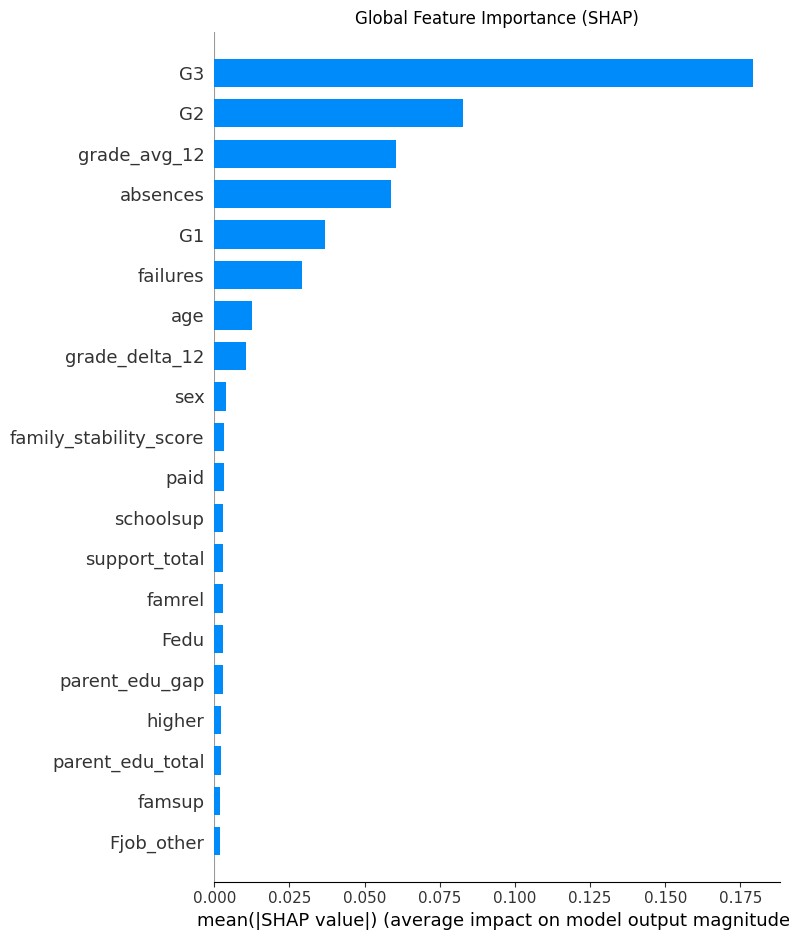

In [ ]:
shap.summary_plot(shap_values_pos, X_test_best, plot_type = "bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig(project_root / "reports" / "figures" / "shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.show()

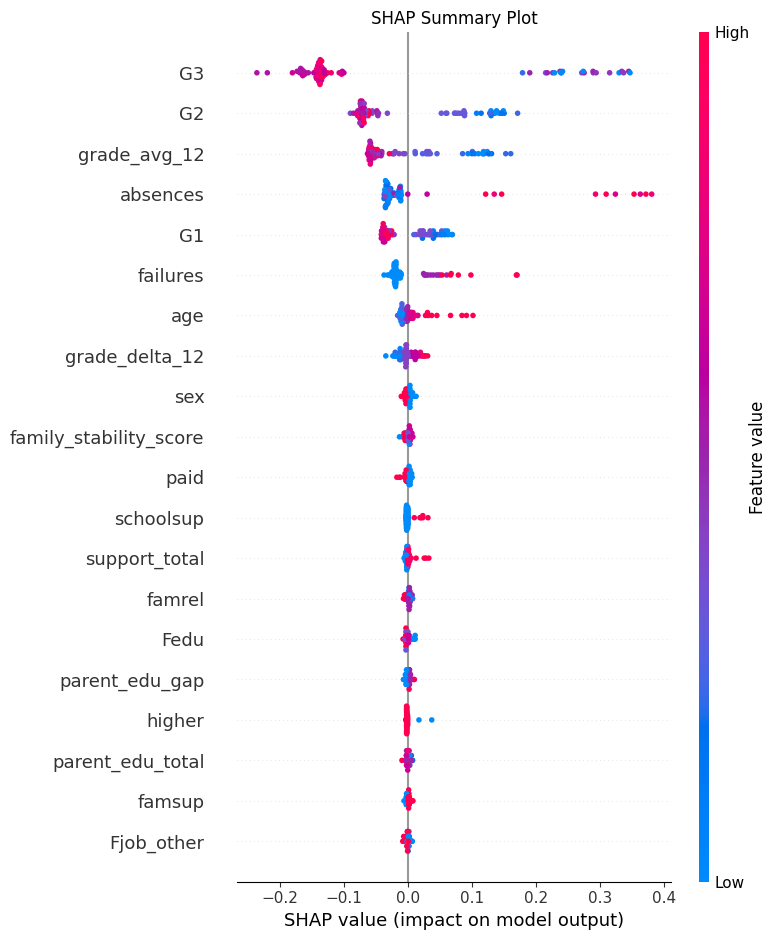

In [ ]:
shap.summary_plot(shap_values_pos, X_test_best, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig(project_root / "reports" / "figures" / "shap_summary_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_test_best.columns,
    "mean_abs_shap": np.abs(shap_values_pos).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

feature_importance.head()

,feature,mean_abs_shap
19,G3,0.179222
18,G2,0.082704
30,grade_avg_12,0.060319
16,absences,0.058791
17,G1,0.036735


In [ ]:
feature_importance_path = project_root / "reports" / "shap_feature_importance.csv"
feature_importance.to_csv(feature_importance_path, index=False)

print(f"Saved feature importance to: {feature_importance_path}")

Saved feature importance to: /content/drive/MyDrive/fee-defaulter-prediction/reports/shap_feature_importance.csv


## Interpretation Note

Features with larger mean absolute SHAP values have greater overall infulence on the model's prediction.

A high SHAP importance does not automatically imply causation. It indicates that the model relies strongly on those variables for prediction

## Local Explanation fokr an Individual Student


In addition to global explanations, SHAP can explain a single prediction by showing which features pushed the model toward higher or lower fee-default risk

In [ ]:
sample_idx = 0

print("True Label:", y_test_best.iloc[sample_idx])
print("Predicted probability:", best_model.predict_proba(X_test_best.iloc[[sample_idx]])[:, 1][0])
X_test_best.iloc[[sample_idx]]

True Label: 0
Predicted probability: 0.01


,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Fjob_services,Fjob_teacher,parent_edu_total,parent_edu_gap,grade_avg_12,grade_delta_12,support_total,resource_support_total,access_risk_score,family_stability_score
0,1,17,1,0,1,4,4,2,1,0,...,False,True,8,0,11.0,0,0,1,2,5


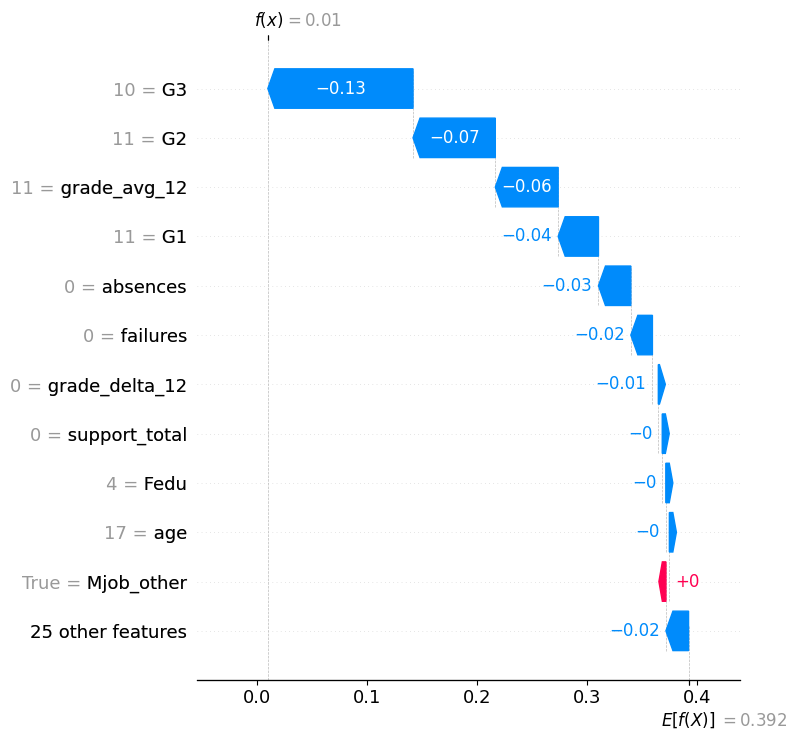

In [ ]:
sample_explanation = shap.Explanation(values=shap_values_pos[sample_idx], base_values=expected_value_pos,
data=X_test_best.iloc[sample_idx].values, feature_names=X_test_best.columns.tolist()
)

shap.plots.waterfall(sample_explanation, max_display=12, show=False)
plt.tight_layout()
plt.savefig(project_root / "reports" / "figures" / "shap_waterfall_sample.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
y_prob = best_model.predict_proba(X_test_best)[:, 1]

high_risk_idx = int(np.argmax(y_prob))
print("Highest preidcted risk index:", high_risk_idx)
print("Highest predicted risk probability:", y_prob[high_risk_idx])
print("True Label:", y_test_best.iloc[high_risk_idx])

Highest preidcted risk index: 39
Highest predicted risk probability: 0.9933333333333333
True Label: 1


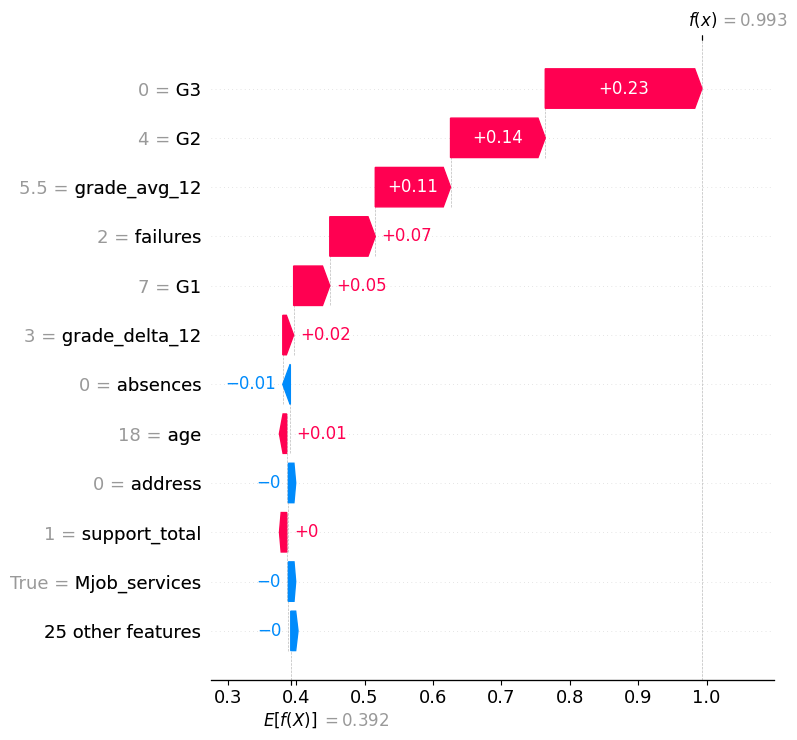

In [ ]:
high_risk_explanation = shap.Explanation(
    values=shap_values_pos[high_risk_idx],
    base_values=expected_value_pos,
    data=X_test_best.iloc[high_risk_idx].values,
    feature_names=X_test_best.columns.tolist()
)

shap.plots.waterfall(high_risk_explanation, max_display=12, show=False)
plt.tight_layout()
plt.savefig(project_root / "reports" / "figures" / "shap_waterfall_high_risk.png", dpi=300, bbox_inches="tight")
plt.show()

## Explainability Summary

This notebook used SHAP to interpret the champion Random Forest model.

The analysis provides:

- global feature importance across the test set
- feature-level direction and magnitude effects
- student-level explanations for individual predictions

These results improve transparency and help evaluate whether the model relies on sensible academic and contextual signals.

## Caution on Interpretation

Because the target variable was engineered partly from academic distress variables such as `G3`, `failures`, and `absences`, strong SHAP importance for these features is expected.

Therefore, the explainability results should be interpreted as showing how the model learned the proxy target definition, rather than as evidence of purely independent causal drivers of fee default.

## Results Interpretation

SHAP analysis showed that the champion Random Forest model relies primarily on academic distress variables, especially `G3`, `G2`, `grade_avg_12`, `absences`, and `G1`.

Lower grades, higher absenteeism, and more prior failures generally pushed predictions toward higher fee-default risk. Higher grades and lower academic distress pushed predictions toward lower risk.

This pattern is consistent with the engineered proxy target and suggests that the model learned meaningful prediction rules from the available data.

## Limitation of Interpretation

Because the target variable was engineered partly from `G3`, `failures`, and `absences`, strong SHAP importance for these features is expected. Therefore, the explainability analysis should be interpreted as explaining the learned proxy-risk rule rather than establishing independent causal drivers of school-fee default.